# Surface spectral functions for semi-infinite systems

A semi-infinite system -- bulk-like far from a boundary, but cleaved along one direction -- has a
surface Green's function computed with a renormalization (decimation) technique, `h.get_surface_kdos`.
Plotting the surface spectral weight `ds` alongside the bulk spectral weight `db` at the same
`(k,e)` reveals topologically-protected edge states living only at the boundary, absent from `db`:
below, Kane-Mele spin-orbit coupling opens a bulk gap, and Rashba coupling (breaking the
$z$-mirror symmetry that otherwise pins the edge states to a fixed spin axis) exposes them clearly.

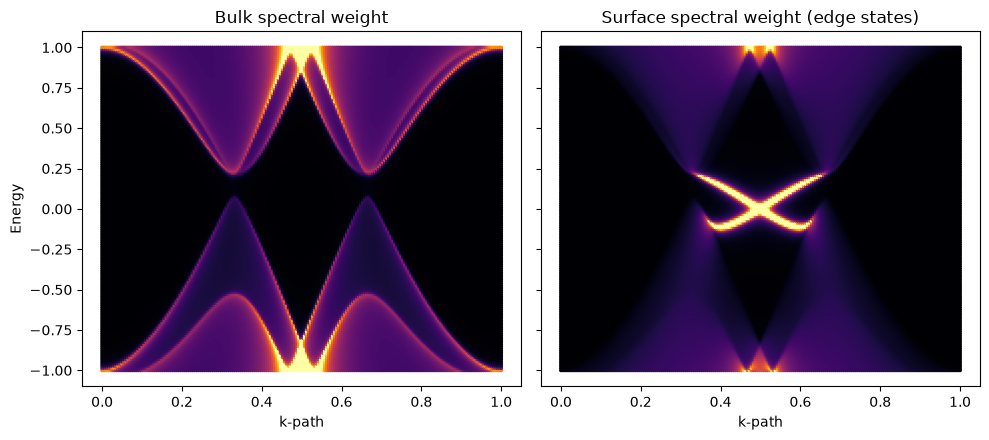

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
g = geometry.honeycomb_lattice()
h = g.get_hamiltonian()
h.add_soc(0.05)     # Kane-Mele spin-orbit coupling: opens a topological gap
h.add_rashba(0.1)   # exposes the helical edge states

(k,e,ds,db) = h.get_surface_kdos(delta=1e-2,nk=200,energies=np.linspace(-1.0,1.0,150))
# a few (k,e) points can land almost exactly on a sharp peak while their neighbors
# miss it -- clip each colorscale at a high percentile instead of the raw max
fig,axs = plt.subplots(1,2,figsize=(10,4.5),sharey=True)
axs[0].scatter(k,e,c=db,cmap="inferno",s=3,vmax=np.percentile(db,99))
axs[0].set_title("Bulk spectral weight") ; axs[0].set_xlabel("k-path") ; axs[0].set_ylabel("Energy")
axs[1].scatter(k,e,c=ds,cmap="inferno",s=3,vmax=np.percentile(ds,99))
axs[1].set_title("Surface spectral weight (edge states)") ; axs[1].set_xlabel("k-path")
plt.tight_layout()
plt.show()